In [3]:
import numpy as np
import pandas as pd
import scipy.stats as sps

from tqdm import tqdm, trange

from functools import partial
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid', font_scale=1.3, palette='Set2')

# Основные понятия статистических критериев

Пусть $\mathscr{X}$ это множество всех возможных значений выборки. Критерием для проверки гипотезы $\mathsf{H}_0$ будем называть множество $S \subset \mathscr{X}$, для которого $\mathsf{H}_0$ отвергается тогда и только тогда, когда $X \in S$.


Рассмотрим пример бросков монетки, в котором выборка имеет бернуллиевское распределение. Пусть мы хотим проверить, правильную ли монету мы подкидываем. В таком случае основная гипотеза $\mathsf{H}_0$ будет состоять в том, что $p=0.5$. 

Давайте сначала возьмем **очень странный критерий**. Допустим, в выборке 100 элеметов. Тогда гипотеза $\mathsf{H}_0\colon p = 0.5$  не будет отвергаться только когда $\sum\limits_{i=1}^n X_i = 50$, то есть в выборке ровно половина единиц.

In [4]:
def crit1(X):
    """
    Первый странный критерий
    X: выборка

    Возвращает 1, если Н0 отвергается.
    """
    return sum(X) != len(X) / 2

Что-то мне подсказывает, что у этого критерия вероятность ошибки первого рода будет далеко не 5%. Проверим это.

Для этого произведем достаточно много итераций:
* генерация выборки размера 100 из распределения Бернулли
* применение критерия, сохранение результата.

В результате этой процедуры мы получаем набор из нулей и единиц по количеству проведенных итераций. Нетрудно догадаться, что этот набор является выборкой из бернуллиевского распределения с параметром, равным вероятности ошибки 1 рода. Соответственно, мы можем привести оценку этой вероятности и построить для нее доверительный интервал. Мы хотели бы сказать, что данный критерий нам подходит если интервал накрывает 5%.

In [5]:
def conf_int(sample_len, sample_sum, alpha=0.95):
    """
    функция возвращает (L, R) - доверительный интервал уровня доверия 
    param: alpha 
        по выборке 
    param: X
    """
    
    p_hat = sample_sum / sample_len
    sigma = np.sqrt((p_hat * (1 - p_hat)) / sample_len)
    q = sps.norm.ppf((1 + alpha) / 2)
    C = (p_hat - q * sigma, p_hat + q * sigma)
    return C


def calculate_1error(crit, n_iter=10000, n=100): 
    """
    функция оценивает вероятность ошибки первого рода
    crit: критерий
    n_iter: число итераций оценивания
    n: размер выборки
    возвращает точечную оценку и доверительный интервал
    """
    n_reject = 0  # число отвержений
    
    for _ in range(n_iter):
        X = np.random.binomial(n=1, p=0.5, size=n)
        n_reject += crit(X)
    
    C = conf_int(n_iter, n_reject)
    return n_reject / n_iter, C

In [6]:
calculate_1error(crit1)

(0.9168, (0.9113868874575269, 0.922213112542473))

Вероятность ошибки первого рода очень большая. 

---

Попробуем теперь другой способ &mdash; критерий Вальда. Кроме разобранного на лекции способа, его можно также построить на основе соответствующего доверительного интервала
$\mathsf P \left(p \in C  \right) \approx 1 - \alpha$, 
где $$C = \left(\widehat p - \widehat \sigma \cdot z_{1 - \frac {\alpha} 2},\ \ \widehat p + \widehat \sigma \cdot z_{1 - \frac {\alpha} 2}\right).$$
Получаем критерий: если $\frac 1 2 \in C$, то гипотеза не отвергается, иначе отвергается.

In [7]:
def crit2(X, alpha=0.05): # возвращает 1, если Н0 не отвергается
    """
    Функция реализует описанный выше критерий.
    X: выборка
    alpha: желаемая ошибка первого рода
    """
    C = conf_int(len(X), np.sum(X), alpha=1-alpha)
    return not(C[0] <= 1/2 <= C[1])

In [8]:
calculate_1error(crit2)

(0.0556, (0.05110878882381765, 0.060091211176182345))

О, этот критерий уже намного лучше.

Посмотрим на вероятность ошибки второго рода. Можно сообразить, что в нашем эксперименте вероятность ошибки второго рода будет зависить от того, насколько наша монетка неправильная. Если $p = 0.5001$, то такую монету очень сложно отличить от "нормальной", а вот если $p=0.9$, то намного проще.

Поэтому давайте построим график вероятности ошибки второго рода в зависимости от $p$. Значения вероятности ошибки 2 рода симметричны относительно $0.5$, поэтому будем строить график на интервале $(0.5, 1)$.

In [9]:
def calculate_2error(crit, p, n_iter=10000, n=100):
        """
        функция оценивает вероятность ошибки 2го рода для p=param:p и возвращает 
            число от 0 до 1 - долю не отвергнутых гипотез
        crit: критерий
        p: параметр распределения Бернулли
        n_iter: число итераций оценивания
        n: размер выборки
        """
        n_pos = 0 # число НЕотвержений

        for _ in range(n_iter):
            X = np.random.binomial(n=1, p=p, size=n)
            n_pos += 1 - crit(X)
        return n_pos / n_iter

def draw_2error(crit, show=True, label='мощность'):
    """
    Функция рисует график вероятности ошибки второго рода критерия
        param:crit в зависимости от p
    """
    
    P = np.linspace(0.51, 1, 50)
    error_line = [] # сюда будем складывать ошибки 
    
    for p in tqdm(P):
        error_line.append(calculate_2error(crit, p, n_iter=10000))
    
    sns.lineplot(x=P, y=error_line, label=label, lw=3)
    plt.xlabel("Параметр $p$")
    plt.ylabel("Вер-ть ошибка второго рода")
    plt.title("Вер-ть ошибки второго рода в зависимости от $p$")
    if show:
        plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:58<00:00,  1.17s/it]


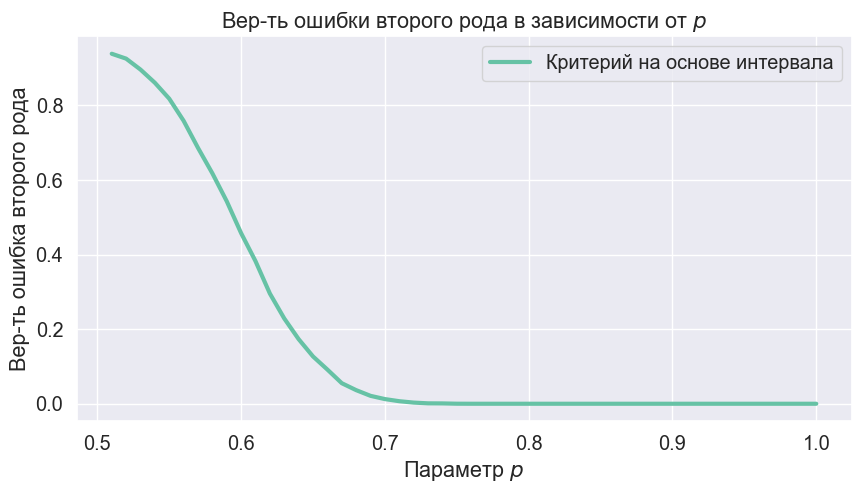

In [10]:
plt.figure(figsize=(10, 5))
draw_2error(crit2, label='Критерий на основе интервала')

Видно, что наш критерий работает логично: при $p$ близких к $0.5$ доля отвержений мала.

Посмотрим для интереса на такой же график, но для первого критерия. Как вы думаете, какой вид будет у него?

100%|██████████| 50/50 [00:07<00:00,  6.74it/s]


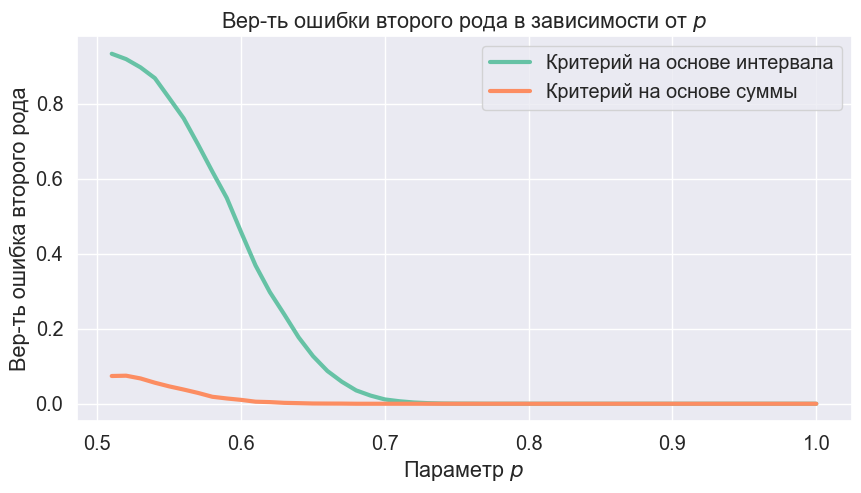

In [11]:
plt.figure(figsize=(10, 5))
draw_2error(crit2, show=False, label='Критерий на основе интервала')
draw_2error(crit1, label='Критерий на основе суммы')

 Хотя первый критерий не может похвастаться маленькой ошибкой первого рода, с ошибкой второго рода у него все в порядке. Но все же ошибка 1 рода для нас более критична, и первый критерий не может ее контролировать на должном уровне. Поэтому далее первый критерий необходимо исключить из рассмотрения.

Теперь давайте внесем некоторые изменения. Во-первых, вместо ошибки второго рода будем рассматривать **мощность** как более традиционную метрику. Во-вторых, попробуем теперь менять не только $p$ для неправильной монетки, но и размер выборки $n$.

In [13]:
def calculate_power(p, crit=crit2, n=100, n_iter=10000):
    """
    функция возвращает мощность критерия для рассматриваемого эксперимента
    param crit: критерий
    param n: размер выборки
    param p: параметр распределения Бернулли
    param n_iter: число итераций
    """
    return 1 - calculate_2error(crit, p=p, n=n, n_iter=n_iter)

In [15]:
n_grid = [10, 50, 100, 250, 500]
p_grid = np.linspace(0, 1, 50) #np.linspace(0.5, 1, 50)
powers = np.zeros((len(n_grid), len(p_grid) ))

# заполним теперь таблицу
for i, n in enumerate((n_grid)):
    for j, p in enumerate(tqdm(p_grid)):
        powers[i, j] = calculate_power(p=p,n=n, n_iter=1000)

100%|██████████| 50/50 [00:05<00:00,  8.56it/s]


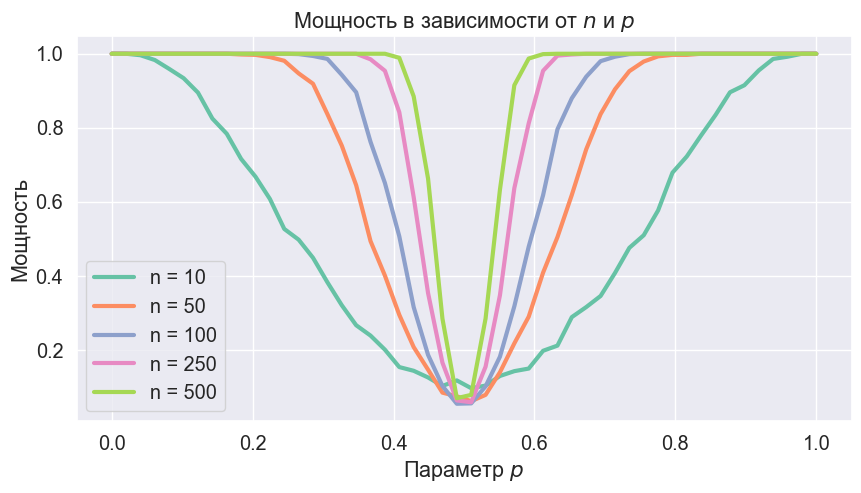

In [16]:
plt.figure(figsize=(10, 5))
for i, n in enumerate(n_grid):
    sns.lineplot(x=p_grid, y=powers[i], label=f"n = {n}", lw=3)
plt.xlabel("Параметр $p$")
plt.ylabel("Мощность")
plt.title("Мощность в зависимости от $n$ и $p$")
plt.show()

Видно, что при фиксированном $p$ мощность растет при росте $n$. Это логично, так как нам по сути с ростом n поступает больше информации по монетке.

🙃